In [6]:
import cv2 as cv
import cv2

import matplotlib.pyplot as plt

import numpy as np

from skimage import filters
from skimage import feature
from scipy.ndimage import distance_transform_edt
from skimage import morphology,segmentation
from skimage import color
from sklearn.cluster import KMeans
from skimage import measure
import scipy.ndimage as ndi

from Sobel import sobel

In [15]:
img1 = cv2.imread('Lamina_1.jpg')
#convert image to gray scale
img_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) 

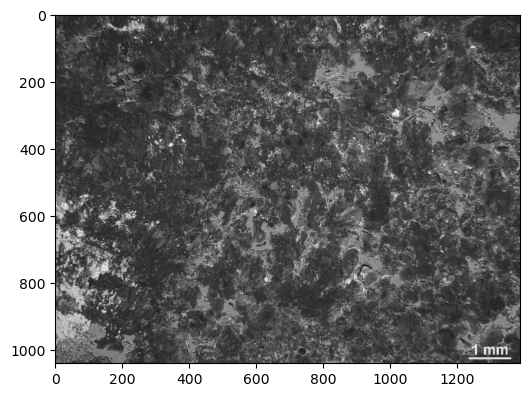

In [16]:
# display the image,figsize; defind size of image
plt.figure(figsize=(6,6))
plt.imshow(img_gray,cmap='gray') 

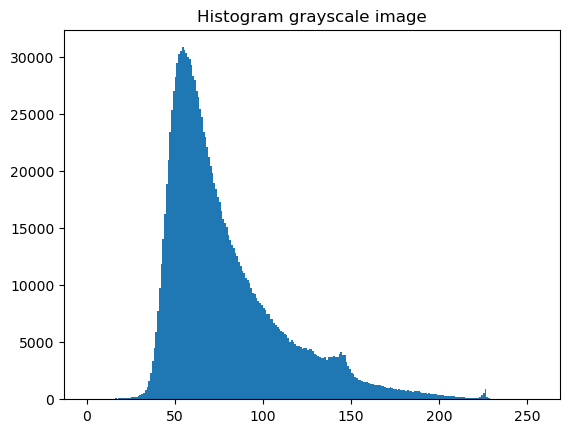

In [17]:
#Histogram for gray scale
plt.hist(img_gray.ravel(),256,[0, 256])
plt.title('Histogram grayscale image')
plt.show() 

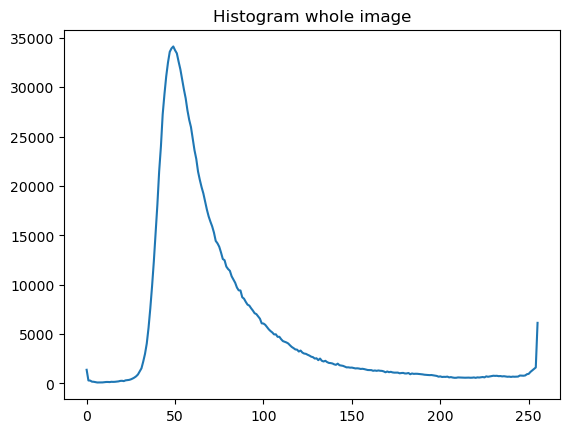

In [18]:
#Histogram for whole image
hist1=cv.calcHist([img1],[0],None,[256],[0,256])
plt.plot(hist1)
plt.title('Histogram whole image')
plt.show() 

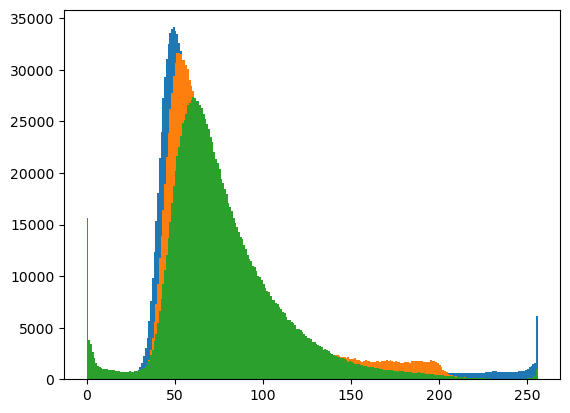

In [19]:
#Histogram for colour image
b,g,r =cv.split(img1)
plt.hist(b.ravel(),256,[0, 256])
plt.hist(g.ravel(),256,[0, 256])
plt.hist(r.ravel(),256,[0, 256])
plt.show() 


In [20]:
# measure size of the image
dim=img1.shape
size=dim[0]*dim[1] 


In [22]:
# filter the image: changing values of filter to obtain better filter
median_blur = cv2.medianBlur(img_gray,5)
blur = cv.GaussianBlur(median_blur,(1,1),0)
img = filters.median(blur, np.ones((8,8)))

In [24]:
#Thrsholding; to convert the image to Binary image
threshold = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C
                                  ,cv2.THRESH_BINARY,115,1)

In [25]:
#To find the fact edges location
laplacian_2 = cv2.Laplacian(threshold,cv2.CV_8U,-1) 

In [26]:
#Canny detection using to detect the edges
edged = cv2.Canny(laplacian_2,40,100) 

In [27]:
#Dilation using to extend the edges of items and denoise the edges
edged = cv2.dilate(edged, None, iterations=1) 

In [28]:
# Erosion using to maintain the primary edges of objects in forground
edged = cv2.erode(edged, None, iterations=1) 

In [29]:
#Using to calculate Euclidean distance from each pixel to the bachground
dt = distance_transform_edt(~edged)

Peaks index: [[ 544  973]
 [ 562  976]
 [ 328 1357]
 [ 797  156]]


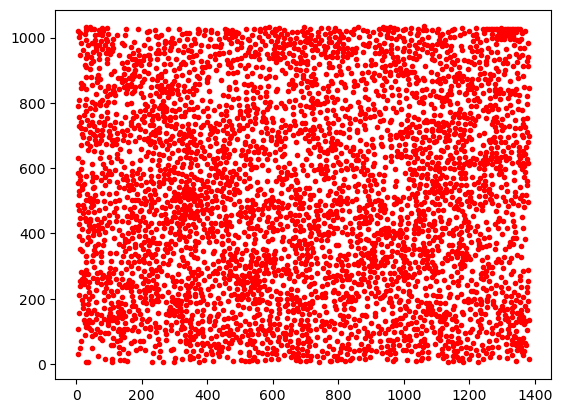

In [52]:
#locate the peaks (peaks are separated by at least min_distance ;
# indices=TRUE : peak coordinates in output)peak_idx
# indices=FALSE : image with peaks in output)local_max
local_max = ndi.maximum_filter(dt, size=5, mode='constant')
#local_max = feature.peak_local_max(dt,exclude_border=False,min_distance=10)

# min_distance can be change to obtaine best observation through range(10,20)
peak_idx = feature.peak_local_max(dt, min_distance=5)

print('Peaks index:',peak_idx[:4]) # print four peaks in the image
plt.plot(peak_idx[:,1],peak_idx[:,0],'r.')

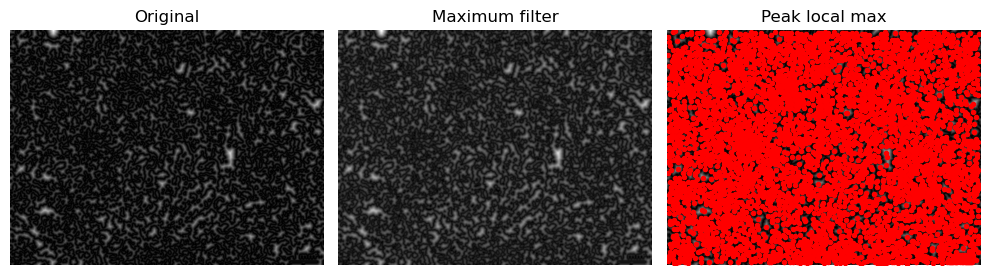

In [53]:
# display results
fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(dt, cmap=plt.cm.gray)
ax[0].axis('off')
ax[0].set_title('Original')

ax[1].imshow(local_max, cmap=plt.cm.gray)
ax[1].axis('off')
ax[1].set_title('Maximum filter')

ax[2].imshow(dt, cmap=plt.cm.gray)
ax[2].autoscale(False)
ax[2].plot(peak_idx[:, 1], peak_idx[:, 0], 'r.')
ax[2].axis('off')
ax[2].set_title('Peak local max')

fig.tight_layout()

plt.show()

In [54]:
#Peaks label in the image
markers = measure.label(local_max)

In [56]:
#Segment and do watershed on the image
labels = segmentation.watershed(-dt, markers)
seg=(segmentation.mark_boundaries(edged,labels)) 

In [ ]:
#Split regions with their intensity in the image
regions = measure.regionprops(labels, intensity_image=img)
#measure labels and area
for prop in regions:
    print('Label:{} Area:{}' .format(prop.label, prop.area))
region_means = [r.mean_intensity for r in regions]
print(region_means)


In [58]:
#Choose the number of k_clusters from range K=[1,6] clusters
# it can be change to obtain best observation through this range [1,6]
k_clusters=4
model = KMeans(k_clusters) 

In [59]:
#Reshape the format of regions
region_means = np.array(region_means).reshape(-1, 1)
model.fit(region_means) 

c:\Users\DELL\miniconda3\envs\python_v3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4)

In [60]:
#Defind specific labels
four_labels = model.predict(region_means) 

In [61]:
#Return a copy of the array.
classified_labels = labels.copy() 

Text(0.5, 1.0, 'Classified and labels image')

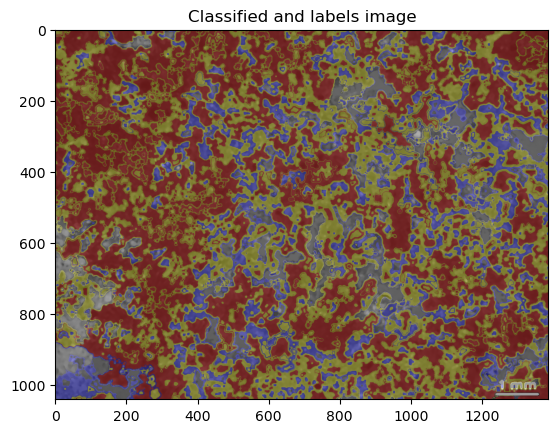

In [62]:
#Plott specific labels and colorize it
for six, region in zip(four_labels, regions):
 classified_labels[tuple(region.coords.T)] = six
plt.imshow(color.label2rgb( classified_labels,image=img))
plt.title('Classified and labels image') 

In [63]:
#Calculate regions area of objects or labels
area =[np.sum(classified_labels==val) for val in range(0,5)]
print('Area for each cluster',area) 


Area for each cluster [114827, 561732, 213175, 553786, 0]


In [65]:
#To calculate the ratio of each object in the image
ratio1 = 100 * np.sum(classified_labels == 0) / size
print ('Ratio1 is : ', round(ratio1,1),'%')
ratio2 = 100 * np.sum(classified_labels == 1) / size
print ('Ratio2 is : ', round(ratio2,1),'%')
np.count_nonzero( classified_labels)
ratio3 = 100 * np.sum(classified_labels == 2) / size
print ('Ratio3 is : ', round(ratio3,1),'%')
ratio4 = 100 * np.sum(classified_labels == 3) / size
print ('Ratio4 is : ', round(ratio4,1),'%')
ratio5 = 100 * np.sum(classified_labels == 4) / size
print ('Ratio5 is : ', round(ratio5,1),'%')
ratio6 = 100 * np.sum(classified_labels == 5) / size
print ('Ratio6 is : ', round(ratio6,1),'%') 


Ratio1 is :  8.0 %
Ratio2 is :  38.9 %
Ratio3 is :  14.8 %
Ratio4 is :  38.4 %
Ratio5 is :  0.0 %
Ratio6 is :  0.0 %


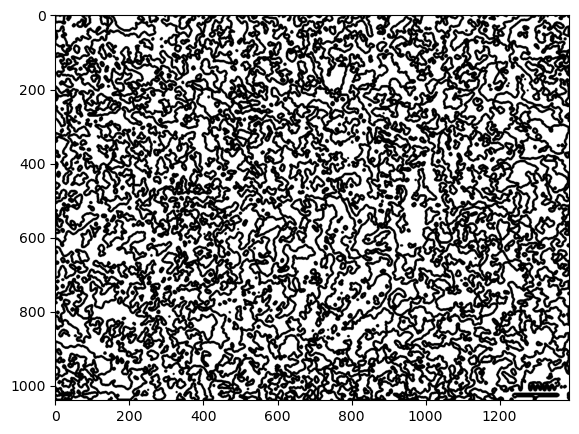

In [67]:
# To calculate the eara using FinContours (calculate background here)
contours2, hierarchy2 = cv2.findContours(threshold,
                                         cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
width,hight =threshold.shape
b = []
Areal = 0
for i in range(1,len(contours2)):
 b.append(contours2[i])
 a = cv.contourArea(contours2[i])
 Areal += a
# draw contours around found object and display
e_img = np.full((width,hight), 255,np.uint8)
cv.drawContours(e_img,b,-1, 0, thickness=5)
plt.figure(figsize=(10,5))
plt.imshow(e_img,cmap='gray')
plt.show()